# Advanced Multi-Target Classification of Cybersecurity Threats
## Leakage-Safe XGBoost + CatBoost Ensemble with ML-SMOTE and SHAP — CIC-DDoS2019

This notebook is the **revised** experimental pipeline, rebuilt on the large, public
**CIC-DDoS2019** benchmark (cleaned parquet release) in direct response to the reviewers.
Every figure and number in the revised manuscript is produced here.

**Reviewer-driven changes reflected in this notebook**
- Moved from the tiny 1,234-row "Data Breaches" set (two *constant* labels giving vacuous
  AUC=1.000) to CIC-DDoS2019 (**125,170** labelled flows; a **40,000**-flow stratified
  working sample, ~32x larger) — *R2.6, R2.17.1, R2.17.2*.
- Four **non-constant**, security-meaningful, hierarchical targets — *R2.6, R2.17.1*.
- Explicit **ML-SMOTE** definition + comparison against ROS/SMOTE/ADASYN/SMOTEENN — *R2.7, R2.17.4*.
- Documented **ensemble weight grid search** (inner CV) — *R1.2, R2.8*.
- **Binary Relevance vs Classifier Chains vs Label Powerset** comparison — *R2.17.3, R2.17.5*.
- **PR-AUC / F1 / balanced-accuracy / full confusion matrices** with real FP/FN — *R2.10, R2.17.6*.
- **Wilcoxon signed-rank** tests with **Holm–Bonferroni** correction — *R2.11, R2.17.6*.
- **SHAP with real feature names** (global + local) — *R1.3, R1.4, R2.9*.
- **Runtime / throughput / memory** profiling for SIEM claims — *R2.12, R2.17.7*.


## 0. Environment and reproducibility

In [1]:
import sys, platform, time, json, warnings, random, os, resource
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import xgboost as xgb
from catboost import CatBoostClassifier
import shap
print("Python :", platform.python_version())
print("NumPy  :", np.__version__, "| pandas:", pd.__version__)
print("XGBoost:", xgb.__version__, "| SHAP:", shap.__version__)
print("CPU    :", platform.processor() or platform.machine())

SEED = 42
random.seed(SEED); np.random.seed(SEED)
SAMPLE_N = 40000

Python : 3.12.3
NumPy  : 2.4.4 | pandas: 3.0.2
XGBoost: 3.4.1 | SHAP: 0.52.0
CPU    : x86_64


## 1. Load CIC-DDoS2019 and derive the multi-target labels

The cleaned CIC-DDoS2019 release provides 77 numeric flow-statistics features plus a
ground-truth `Label`. We build **four binary targets** from the official DDoS taxonomy
(Sharafaldin et al., 2019). They form a genuine **hierarchy**
(`IsPortmap`, `IsNetBIOS` ⊂ `IsReflection` ⊂ `IsAttack`) and span the difficulty spectrum,
so we can demonstrate the framework on both easy and hard-to-predict labels. Crucially,
**none is constant** — the defect the reviewers identified in the previous dataset.

In [2]:
import glob
DATA_DIR = "/tmp/data"
# If only the zip is present, extract it first:
if not glob.glob(os.path.join(DATA_DIR, "*training.parquet")):
    import zipfile
    os.makedirs(DATA_DIR, exist_ok=True)
    zpath = next((p for p in ["cicids-2019.zip", "/mnt/user-data/uploads/cicids-2019.zip"]
                  if os.path.exists(p)), None)
    if zpath: zipfile.ZipFile(zpath).extractall(DATA_DIR)

files = sorted(glob.glob(os.path.join(DATA_DIR, "*training.parquet")))
full = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)
full = full.replace([np.inf, -np.inf], np.nan)
print("Full training pool:", full.shape)
print(full["Label"].value_counts().to_string())

Full training pool: (125170, 78)
Label
Syn        48840
Benign     46427
UDP        18090
MSSQL       8523
LDAP        1906
Portmap      685
NetBIOS      644
UDPLag        55


In [3]:
from sklearn.model_selection import train_test_split
df, _ = train_test_split(full, train_size=SAMPLE_N, stratify=full["Label"],
                         random_state=SEED)
df = df.reset_index(drop=True)

REFLECTION = ["LDAP","MSSQL","NetBIOS","Portmap","DNS","NTP","SNMP","TFTP","SSDP"]
TARGETS = ["IsAttack","IsReflection","IsPortmap","IsNetBIOS"]

Y = pd.DataFrame(index=df.index)
Y["IsAttack"]     = (df["Label"] != "Benign").astype(int)     # common threat (easy)
Y["IsReflection"] = df["Label"].isin(REFLECTION).astype(int)  # amplification family (moderate)
Y["IsPortmap"]    = (df["Label"] == "Portmap").astype(int)    # rare subtype (hard)
Y["IsNetBIOS"]    = (df["Label"] == "NetBIOS").astype(int)    # rare subtype (hard)

feats = [c for c in df.columns if c != "Label"]   # 77 flow features; no target uses a feature -> leakage-safe
X = df[feats]

print("Working sample:", df.shape, "| features:", len(feats))
print("\nPositive rates (NONE is constant):")
for t in TARGETS:
    print(f"  {t:15s} {100*Y[t].mean():6.2f}%   n_pos={int(Y[t].sum()):,}")
print("\nLabel correlation matrix (genuine label dependency):")
print(Y.corr().round(3).to_string())

Working sample: (40000, 78) | features: 77

Positive rates (NONE is constant):
  IsAttack         62.91%   n_pos=25,164
  IsReflection      9.40%   n_pos=3,758
  IsPortmap         0.55%   n_pos=219
  IsNetBIOS         0.52%   n_pos=206

Label correlation matrix (genuine label dependency):
              IsAttack  IsReflection  IsPortmap  IsNetBIOS
IsAttack         1.000         0.247      0.057      0.055
IsReflection     0.247         1.000      0.230      0.223
IsPortmap        0.057         0.230      1.000     -0.005
IsNetBIOS        0.055         0.223     -0.005      1.000


## 2. Leakage-safe preprocessing and ML-SMOTE

**Preprocessing** (median imputation, `log1p` on heavy-tailed magnitude features,
z-score standardisation) is **fit on the training fold only** and applied to the validation
fold, so no validation statistics leak into training.

**ML-SMOTE** (Charte, Rivera, del Jesus & Herrera, *Knowledge-Based Systems*, 2015) is the
multi-label extension of SMOTE. It oversamples instances carrying *tail* (minority) labels
by feature-space interpolation and assigns each synthetic instance a **label-set** via
neighbour majority vote — unlike standard SMOTE, which handles one binary target at a time
and cannot respect co-occurring labels. Its known downside (synthetic noise / possible label
-dependency violation) is examined empirically in Section 6.

In [4]:
from sklearn.neighbors import NearestNeighbors
LOG_FEATURES = ["Flow Duration","Flow Bytes/s","Flow Packets/s","Fwd Packets Length Total",
    "Bwd Packets Length Total","Flow IAT Mean","Flow IAT Max","Fwd IAT Total","Bwd IAT Total",
    "Fwd Header Length","Bwd Header Length","Packet Length Variance","Subflow Fwd Bytes",
    "Subflow Bwd Bytes","Active Mean","Idle Mean"]

def fit_preprocess(Xtr):
    logset = [c for c in LOG_FEATURES if c in Xtr.columns]
    med = Xtr.median(numeric_only=True); Xt = Xtr.fillna(med)
    for c in logset: Xt[c] = np.log1p(np.clip(Xt[c].values, 0, None))
    mu = Xt.mean(); sd = Xt.std().replace(0, 1.0)
    return ((Xt-mu)/sd).astype("float32"), dict(logset=logset, med=med, mu=mu, sd=sd)

def apply_preprocess(X, p):
    Xt = X.fillna(p["med"])
    for c in p["logset"]: Xt[c] = np.log1p(np.clip(Xt[c].values, 0, None))
    return ((Xt-p["mu"])/p["sd"]).astype("float32")

def _irlbl(Yy):
    c = Yy.sum(axis=0).astype(float); c[c==0] = 1.0; return c.max()/c
def get_tail_labels(Yy):
    ir = _irlbl(Yy); return list(ir[ir > ir.mean()].index)

def mlsmote(Xdf, Ydf, n_sample, k=5, seed=SEED):
    rng = random.Random(seed); tail = get_tail_labels(Ydf)
    if not tail or n_sample <= 0: return Xdf, Ydf
    mask = Ydf[tail].sum(axis=1) > 0
    Xs = Xdf[mask].reset_index(drop=True); Ys = Ydf[mask].reset_index(drop=True)
    if len(Xs) <= k: return Xdf, Ydf
    nn = NearestNeighbors(n_neighbors=k+1).fit(Xs.values)
    _, idx = nn.kneighbors(Xs.values)
    Xv, Yv, n = Xs.values, Ys.values, len(Xs)
    nX = np.zeros((n_sample, Xs.shape[1]), "float32"); nY = np.zeros((n_sample, Ys.shape[1]), int)
    for i in range(n_sample):
        r = rng.randrange(n); nb = rng.choice(idx[r,1:])
        nY[i] = (Yv[idx[r]].sum(0) >= (k+1)/2.0).astype(int)
        g = rng.random(); nX[i] = Xv[r] - g*(Xv[r]-Xv[nb])
    aX = pd.concat([Xdf, pd.DataFrame(nX, columns=Xdf.columns)], ignore_index=True)
    aY = pd.concat([Ydf, pd.DataFrame(nY, columns=Ydf.columns)], ignore_index=True)
    return aX.astype("float32"), aY

print("Tail (minority) labels selected by ML-SMOTE:", get_tail_labels(Y))

Tail (minority) labels selected by ML-SMOTE: ['IsPortmap', 'IsNetBIOS']


## 3. Ensemble weight selection (inner 3-fold CV) — *R1.2, R2.8*

The soft-voting weight `w` (applied as `w·P_XGB + (1-w)·P_CatBoost`) is tuned by grid
search over `w ∈ {0.00, 0.05, …, 1.00}` using an **inner 3-fold** stratified CV, scored by
macro PR-AUC. Both base models are trained once per inner fold and the weight is swept
analytically over the cached probabilities. We report the full grid so the reader can judge
robustness.

In [5]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score

XGB_PARAMS = dict(n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.9,
                  colsample_bytree=0.9, n_jobs=1, tree_method="hist", verbosity=0,
                  eval_metric="logloss", random_state=SEED)
CB_PARAMS = dict(iterations=200, depth=6, learning_rate=0.1, verbose=0,
                 thread_count=1, random_seed=SEED)

def train_pair(Xtr, ytr, Xva):
    m1 = xgb.XGBClassifier(**XGB_PARAMS)
    if ytr.sum() > 0:
        m1.set_params(scale_pos_weight=float(np.clip((len(ytr)-ytr.sum())/max(ytr.sum(),1),1,200)))
    m1.fit(Xtr, ytr); p1 = m1.predict_proba(Xva)[:,1]
    m2 = CatBoostClassifier(**CB_PARAMS); m2.fit(Xtr, ytr); p2 = m2.predict_proba(Xva)[:,1]
    return p1, p2

inner = StratifiedKFold(3, shuffle=True, random_state=SEED)
cache = {t: [] for t in TARGETS}
for tr, va in inner.split(X, df["Label"]):
    Xtr, prm = fit_preprocess(X.iloc[tr].copy()); Xva = apply_preprocess(X.iloc[va].copy(), prm)
    Ytr = Y.iloc[tr].reset_index(drop=True)
    Xr, Yr = mlsmote(Xtr.reset_index(drop=True), Ytr, int(0.5*len(Xtr)))
    for t in TARGETS:
        p1, p2 = train_pair(Xr.values, Yr[t].values, Xva.values)
        cache[t].append((Y.iloc[va][t].values, p1, p2))

grid = [round(w,2) for w in np.arange(0,1.01,0.05)]
wtable = []
for w in grid:
    prs = [np.mean([average_precision_score(yv, w*p1+(1-w)*p2)
                    for (yv,p1,p2) in cache[t] if len(np.unique(yv))>1]) for t in TARGETS]
    wtable.append((w, float(np.mean(prs))))
W = max(wtable, key=lambda r: r[1])[0]
print("w_XGB | macro PR-AUC")
for w, s in wtable:
    print(f"  {w:.2f} | {s:.4f}" + ("   <-- selected" if w==W else ""))
print(f"\nSelected weight: XGBoost={W}, CatBoost={round(1-W,2)}")

w_XGB | macro PR-AUC
  0.00 | 0.7834
  0.05 | 0.7843
  0.10 | 0.7856
  0.15 | 0.7865
  0.20 | 0.7866
  0.25 | 0.7868
  0.30 | 0.7873
  0.35 | 0.7877
  0.40 | 0.7885
  0.45 | 0.7896
  0.50 | 0.7897
  0.55 | 0.7900
  0.60 | 0.7897
  0.65 | 0.7896
  0.70 | 0.7895
  0.75 | 0.7895
  0.80 | 0.7899
  0.85 | 0.7902
  0.90 | 0.7902   <-- selected
  0.95 | 0.7897
  1.00 | 0.7880

Selected weight: XGBoost=0.9, CatBoost=0.1


## 4. Outer 5-fold cross-validation — ensemble vs single-target baselines

Per fold and per target we report **ROC-AUC, PR-AUC, F1, balanced accuracy**, and accumulate
the **confusion matrix** (real TN/FP/FN/TP). Per-fold arrays are retained for the significance
tests in Section 7.

In [6]:
from sklearn.metrics import (roc_auc_score, f1_score, balanced_accuracy_score,
                             confusion_matrix)
def metric_row(y, p):
    yh = (p>=0.5).astype(int); tn,fp,fn,tp = confusion_matrix(y,yh,labels=[0,1]).ravel()
    return dict(roc=roc_auc_score(y,p) if len(np.unique(y))>1 else np.nan,
                pr=average_precision_score(y,p) if len(np.unique(y))>1 else np.nan,
                f1=f1_score(y,yh,zero_division=0), bal=balanced_accuracy_score(y,yh),
                tn=int(tn),fp=int(fp),fn=int(fn),tp=int(tp))

outer = StratifiedKFold(5, shuffle=True, random_state=SEED)
pf = {m:{t:[] for t in TARGETS} for m in ["xgb","catboost","ensemble"]}
cmsum = {m:{t:np.zeros(4,int) for t in TARGETS} for m in ["xgb","catboost","ensemble"]}
t0=time.time()
for k,(tr,va) in enumerate(outer.split(X, df["Label"]),1):
    Xtr,prm=fit_preprocess(X.iloc[tr].copy()); Xva=apply_preprocess(X.iloc[va].copy(),prm)
    Ytr=Y.iloc[tr].reset_index(drop=True)
    Xr,Yr=mlsmote(Xtr.reset_index(drop=True),Ytr,int(0.5*len(Xtr)))
    for t in TARGETS:
        yv=Y.iloc[va][t].values; p1,p2=train_pair(Xr.values,Yr[t].values,Xva.values)
        for name,p in [("xgb",p1),("catboost",p2),("ensemble",W*p1+(1-W)*p2)]:
            r=metric_row(yv,p); pf[name][t].append(r)
            cmsum[name][t]+=np.array([r["tn"],r["fp"],r["fn"],r["tp"]])
    print(f"  fold {k} done ({time.time()-t0:.0f}s)")

def summarise(m,t):
    rows=pf[m][t]
    return {k:(float(np.nanmean([r[k] for r in rows])),float(np.nanstd([r[k] for r in rows])))
            for k in ["roc","pr","f1","bal"]}
print("\n%-14s %-9s %8s %8s %8s %8s"%("target","model","ROC","PR-AUC","F1","BalAcc"))
for t in TARGETS:
    for m in ["xgb","catboost","ensemble"]:
        s=summarise(m,t)
        print("%-14s %-9s %8.4f %8.4f %8.4f %8.4f"%(t,m,s["roc"][0],s["pr"][0],s["f1"][0],s["bal"][0]))

  fold 1 done (32s)


  fold 2 done (64s)


  fold 3 done (96s)


  fold 4 done (128s)


  fold 5 done (160s)

target         model          ROC   PR-AUC       F1   BalAcc
IsAttack       xgb         1.0000   1.0000   0.9993   0.9992
IsAttack       catboost    1.0000   1.0000   0.9991   0.9990
IsAttack       ensemble    1.0000   1.0000   0.9993   0.9992
IsReflection   xgb         0.9995   0.9954   0.9719   0.9901
IsReflection   catboost    0.9994   0.9945   0.9697   0.9903
IsReflection   ensemble    0.9995   0.9955   0.9719   0.9904
IsPortmap      xgb         0.9913   0.5247   0.5339   0.8309
IsPortmap      catboost    0.9870   0.5229   0.5567   0.8266
IsPortmap      ensemble    0.9912   0.5313   0.5324   0.8264
IsNetBIOS      xgb         0.9944   0.7074   0.6379   0.8699
IsNetBIOS      catboost    0.9895   0.6949   0.6641   0.8630
IsNetBIOS      ensemble    0.9941   0.7063   0.6459   0.8723


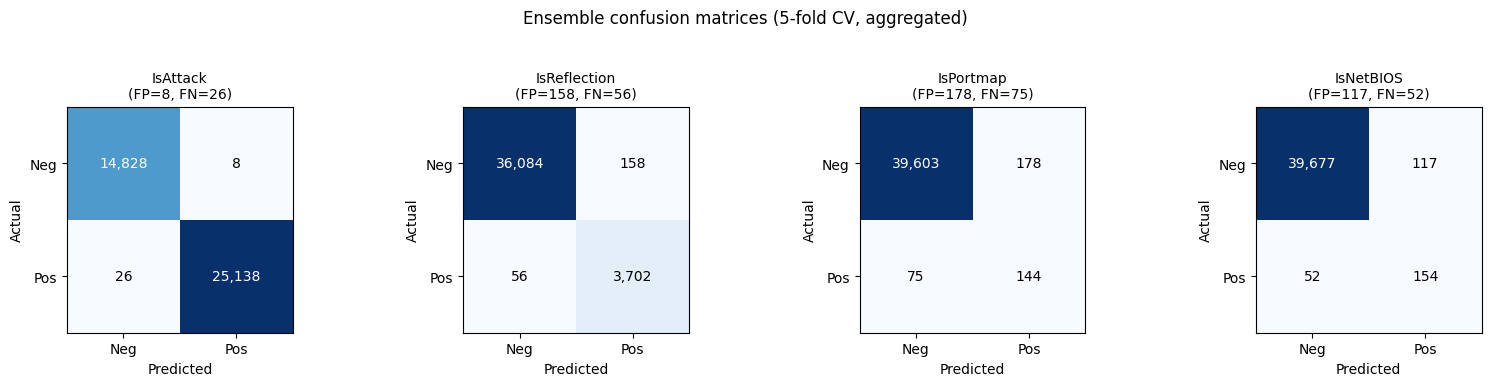

In [7]:
# Confusion matrices (ensemble, aggregated over folds) with real FP / FN
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,4,figsize=(16,3.6))
for a,t in zip(ax,TARGETS):
    tn,fp,fn,tp=cmsum["ensemble"][t]; M=np.array([[tn,fp],[fn,tp]])
    a.imshow(M,cmap="Blues")
    for (r,c),v in np.ndenumerate(M):
        a.text(c,r,f"{v:,}",ha="center",va="center",
               color="white" if v>M.max()/2 else "black")
    a.set_xticks([0,1]); a.set_yticks([0,1]); a.set_xticklabels(["Neg","Pos"])
    a.set_yticklabels(["Neg","Pos"]); a.set_xlabel("Predicted"); a.set_ylabel("Actual")
    a.set_title(f"{t}\n(FP={fp:,}, FN={fn:,})",fontsize=10)
plt.suptitle("Ensemble confusion matrices (5-fold CV, aggregated)",y=1.05)
plt.tight_layout(); plt.show()

## 5. Multi-label strategy comparison: Binary Relevance vs Classifier Chains vs Label Powerset — *R2.17.3, R2.17.5*

Reviewers asked us to either justify Binary Relevance (BR) or explore label-dependency-aware
schemes. We evaluate BR, **Classifier Chains** (hierarchical order), **Label Powerset**, and a
conventional **Random Forest (BR)** baseline on an identical 30% stratified hold-out, reporting
macro PR-AUC, macro F1, Hamming loss and Exact-Match Ratio (subset accuracy).

In [8]:
from sklearn.multioutput import ClassifierChain
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import hamming_loss, accuracy_score

tr,te=train_test_split(np.arange(len(df)),test_size=0.30,stratify=df["Label"],random_state=SEED)
Xtr,prm=fit_preprocess(X.iloc[tr].copy()); Xte=apply_preprocess(X.iloc[te].copy(),prm)
Ytr=Y.iloc[tr].reset_index(drop=True); Yte=Y.iloc[te].values
Xr,Yr=mlsmote(Xtr.reset_index(drop=True),Ytr,int(0.5*len(Xtr)))
Xrv,Yrv=Xr.values,Yr.values
XP=dict(n_estimators=200,max_depth=6,learning_rate=0.1,n_jobs=1,tree_method="hist",
        verbosity=0,random_state=SEED)
mpr=lambda Yt,P: float(np.mean([average_precision_score(Yt[:,i],P[:,i])
        for i in range(P.shape[1]) if len(np.unique(Yt[:,i]))>1]))
mf1=lambda Yt,Yp: float(np.mean([f1_score(Yt[:,i],Yp[:,i],zero_division=0) for i in range(Yp.shape[1])]))

# Binary Relevance
Pbr=np.zeros_like(Yte,float)
for i,t in enumerate(TARGETS):
    m=xgb.XGBClassifier(**XP); yt=Yrv[:,i]
    m.set_params(scale_pos_weight=float(np.clip((len(yt)-yt.sum())/max(yt.sum(),1),1,200)))
    m.fit(Xrv,yt); Pbr[:,i]=m.predict_proba(Xte.values)[:,1]
Ybr=(Pbr>=.5).astype(int)
# Classifier Chains (hierarchical)
cc=ClassifierChain(xgb.XGBClassifier(**XP),order=[0,1,2,3],random_state=SEED); cc.fit(Xrv,Yrv)
Pcc=cc.predict_proba(Xte.values); Ycc=(Pcc>=.5).astype(int)
# Label Powerset
combo=Yrv.dot(1<<np.arange(Yrv.shape[1])); uniq=np.unique(combo); remap={v:i for i,v in enumerate(uniq)}
lp=xgb.XGBClassifier(**XP,objective="multi:softprob",num_class=len(uniq))
lp.fit(Xrv,np.array([remap[v] for v in combo]))
proba=lp.predict_proba(Xte.values); Plp=np.zeros_like(Yte,float)
for b in range(Yte.shape[1]):
    cols=[remap[v] for v in uniq if (v>>b)&1]
    if cols: Plp[:,b]=proba[:,cols].sum(1)
pred=lp.predict(Xte.values); inv={i:v for v,i in remap.items()}
Ylp=np.array([[(inv[int(c)]>>b)&1 for b in range(Yte.shape[1])] for c in pred])
# Random Forest (BR)
Prf=np.zeros_like(Yte,float)
for i in range(len(TARGETS)):
    rf=RandomForestClassifier(n_estimators=200,n_jobs=1,random_state=SEED,class_weight="balanced")
    rf.fit(Xrv,Yrv[:,i]); Prf[:,i]=rf.predict_proba(Xte.values)[:,1]
Yrf=(Prf>=.5).astype(int)

print("%-26s %8s %8s %9s %7s"%("strategy","macroPR","macroF1","Hamming","EMR"))
for nm,P,Yp in [("Binary Relevance (XGB)",Pbr,Ybr),("Classifier Chains (XGB)",Pcc,Ycc),
                ("Label Powerset (XGB)",Plp,Ylp),("Random Forest (BR)",Prf,Yrf)]:
    print("%-26s %8.4f %8.4f %9.4f %7.4f"%(nm,mpr(Yte,P),mf1(Yte,Yp),
          hamming_loss(Yte,Yp),accuracy_score(Yte,Yp)))

strategy                    macroPR  macroF1   Hamming     EMR
Binary Relevance (XGB)       0.8268   0.8032    0.0041  0.9880
Classifier Chains (XGB)      0.7898   0.7945    0.0042  0.9887
Label Powerset (XGB)         0.8292   0.7964    0.0041  0.9888
Random Forest (BR)           0.8017   0.8048    0.0041  0.9881


## 6. Resampling comparison — data behind the ML-SMOTE claim — *R2.7, R2.17.4*

Per-target PR-AUC and F1 on the same hold-out for **no resampling, Random Oversampling,
SMOTE, ADASYN, SMOTEENN** (single-label, applied per target) and **ML-SMOTE** (multi-label).
This supplies the evidence the reviewers asked for and exposes ML-SMOTE's trade-off:
resampling tends to raise minority-class recall/F1 but can slightly lower ranking quality
(PR-AUC) by injecting synthetic noise.

In [9]:
from imblearn.over_sampling import RandomOverSampler, SMOTE, ADASYN
from imblearn.combine import SMOTEENN
focus=["IsReflection","IsPortmap","IsNetBIOS"]; Xb=Xtr.reset_index(drop=True)
samplers={"None":None,"RandomOverSampler":RandomOverSampler(random_state=SEED),
          "SMOTE":SMOTE(random_state=SEED),"ADASYN":ADASYN(random_state=SEED),
          "SMOTEENN":SMOTEENN(random_state=SEED)}
rs={}
for nm,s in samplers.items():
    rs[nm]={}
    for t in focus:
        i=TARGETS.index(t); yt=Ytr.values[:,i]
        Xrr,yrr=(Xb.values,yt) if s is None else s.fit_resample(Xb.values,yt)
        m=xgb.XGBClassifier(**XP); m.fit(Xrr,yrr); p=m.predict_proba(Xte.values)[:,1]
        rs[nm][t]=(average_precision_score(Yte[:,i],p),f1_score(Yte[:,i],(p>=.5).astype(int),zero_division=0))
rs["ML-SMOTE"]={}
for t in focus:
    i=TARGETS.index(t); m=xgb.XGBClassifier(**XP); m.fit(Xrv,Yrv[:,i])
    p=m.predict_proba(Xte.values)[:,1]
    rs["ML-SMOTE"][t]=(average_precision_score(Yte[:,i],p),f1_score(Yte[:,i],(p>=.5).astype(int),zero_division=0))
print("%-18s"%"method"+"".join("%22s"%t for t in focus))
for nm in ["None","RandomOverSampler","SMOTE","ADASYN","SMOTEENN","ML-SMOTE"]:
    print("%-18s"%nm+"".join("   PR=%.3f / F1=%.3f"%rs[nm][t] for t in focus))

method                      IsReflection             IsPortmap             IsNetBIOS
None                 PR=0.995 / F1=0.971   PR=0.620 / F1=0.523   PR=0.771 / F1=0.743
RandomOverSampler    PR=0.995 / F1=0.970   PR=0.604 / F1=0.596   PR=0.770 / F1=0.725
SMOTE                PR=0.995 / F1=0.971   PR=0.590 / F1=0.538   PR=0.689 / F1=0.671
ADASYN               PR=0.994 / F1=0.965   PR=0.570 / F1=0.528   PR=0.659 / F1=0.671
SMOTEENN             PR=0.957 / F1=0.965   PR=0.550 / F1=0.519   PR=0.516 / F1=0.701
ML-SMOTE             PR=0.993 / F1=0.968   PR=0.548 / F1=0.545   PR=0.770 / F1=0.694


## 7. Statistical significance — *R2.11, R2.17.6*

Paired **Wilcoxon signed-rank** test on the 20 (5 folds × 4 targets) matched scores,
comparing the ensemble against each base model on PR-AUC and F1. The family of 4 comparisons
is corrected with **Holm–Bonferroni**.

In [10]:
from scipy.stats import wilcoxon
def holm(ps,names):
    order=np.argsort(ps); m=len(ps); adj=np.empty(m); prev=0
    for rank,idx in enumerate(order):
        prev=max(prev,(m-rank)*ps[idx]); adj[idx]=min(prev,1.0)
    return {names[i]:float(adj[i]) for i in range(m)}
def paired(metric,a,b):
    da=[pf[a][t][k][metric] for t in TARGETS for k in range(5)]
    db=[pf[b][t][k][metric] for t in TARGETS for k in range(5)]
    da,db=np.array(da),np.array(db); d=da-db
    return (1.0 if np.allclose(d,0) else float(wilcoxon(da,db,zero_method="pratt")[1])), float(d.mean())
comps=[("pr","ensemble","xgb"),("pr","ensemble","catboost"),
       ("f1","ensemble","xgb"),("f1","ensemble","catboost")]
names=[f"{a} vs {b} ({'PR-AUC' if mt=='pr' else 'F1'})" for mt,a,b in comps]
raw=[]; diffs={}
for (mt,a,b),nm in zip(comps,names):
    p,d=paired(mt,a,b); raw.append(p); diffs[nm]=d
adj=holm(raw,names)
print("Test: Wilcoxon signed-rank (paired) | n_pairs=20 (5 folds x 4 targets) | Holm-Bonferroni, family=4\n")
print("%-34s %10s %8s %8s"%("comparison","mean_diff","p_raw","p_holm"))
for nm,p in zip(names,raw):
    print("%-34s %+10.5f %8.4f %8.4f"%(nm,diffs[nm],p,adj[nm]))

Test: Wilcoxon signed-rank (paired) | n_pairs=20 (5 folds x 4 targets) | Holm-Bonferroni, family=4

comparison                          mean_diff    p_raw   p_holm
ensemble vs xgb (PR-AUC)             +0.00143   0.3683   1.0000
ensemble vs catboost (PR-AUC)        +0.00520   0.0049   0.0194
ensemble vs xgb (F1)                 +0.00161   0.6509   1.0000
ensemble vs catboost (F1)            -0.01003   0.5378   1.0000


## 8. Explainability with real feature names (SHAP) — *R1.3, R1.4, R2.9*

Because CIC-DDoS2019 features are **named** flow statistics, SHAP is now fully interpretable
(no more "Feature 1575"). We fit the ensemble on the hold-out training split, then explain the
XGBoost member for the `IsReflection` target with a global importance plot and a single-flow
local waterfall.

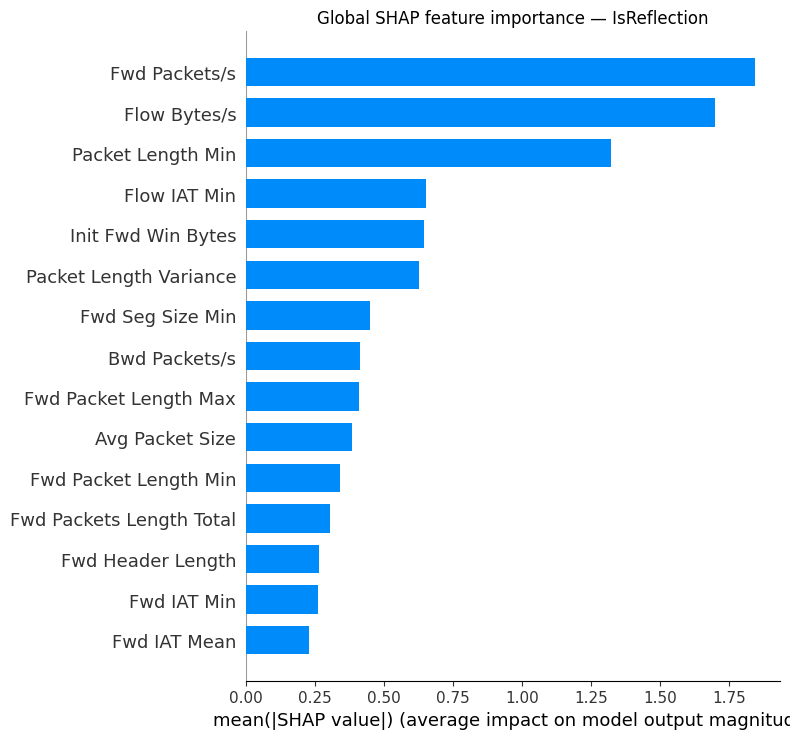

In [11]:
fullmods={}
for t in TARGETS:
    yt=Yr[t].values
    mx=xgb.XGBClassifier(**XGB_PARAMS,
        scale_pos_weight=float(np.clip((len(yt)-yt.sum())/max(yt.sum(),1),1,200)))
    mx.fit(Xr.values,yt)
    mc=CatBoostClassifier(**CB_PARAMS); mc.fit(Xr.values,yt)
    fullmods[t]=(mx,mc)

expl=shap.TreeExplainer(fullmods["IsReflection"][0])
Xs=Xte.sample(min(2000,len(Xte)),random_state=SEED)
sv=expl.shap_values(Xs.values)
shap.summary_plot(sv,Xs,feature_names=feats,plot_type="bar",max_display=15,show=False)
plt.title("Global SHAP feature importance — IsReflection"); plt.tight_layout(); plt.show()

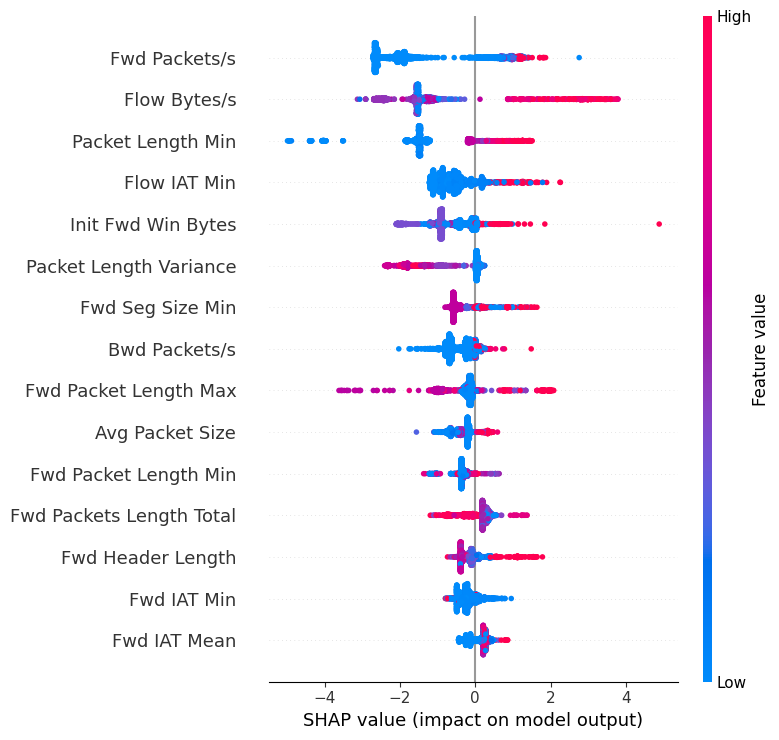

In [12]:
shap.summary_plot(sv,Xs,feature_names=feats,max_display=15,show=False)
plt.tight_layout(); plt.show()

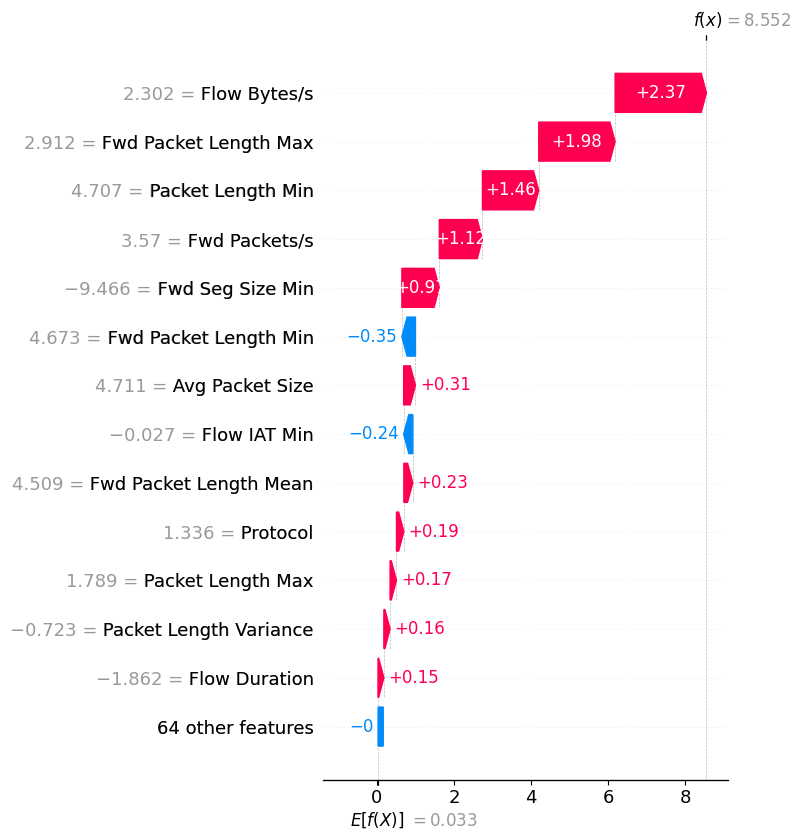

In [13]:
yref=Y.iloc[te]["IsReflection"].values; Xte_r=Xte.reset_index(drop=True)
inst=int(np.where(yref==1)[0][0])
one=expl(Xte_r.iloc[[inst]].values); one.feature_names=feats
shap.plots.waterfall(one[0],max_display=14,show=False); plt.tight_layout(); plt.show()

## 9. Precision–Recall curves

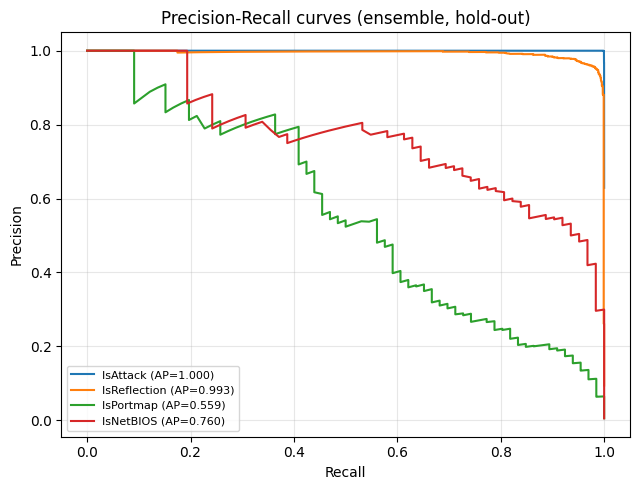

In [14]:
from sklearn.metrics import precision_recall_curve
plt.figure(figsize=(6.5,5))
for t in TARGETS:
    mx,mc=fullmods[t]; p=W*mx.predict_proba(Xte.values)[:,1]+(1-W)*mc.predict_proba(Xte.values)[:,1]
    yv=Y.iloc[te][t].values; pr,rc,_=precision_recall_curve(yv,p)
    plt.plot(rc,pr,label=f"{t} (AP={average_precision_score(yv,p):.3f})")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend(fontsize=8); plt.grid(alpha=.3)
plt.title("Precision-Recall curves (ensemble, hold-out)"); plt.tight_layout(); plt.show()

## 10. Runtime, throughput and memory — SIEM feasibility — *R2.12, R2.17.7*

Timing is reported as a **mean ± SD over repeated inference runs** (peer-review comment 4),
since a single measurement of a timing-sensitive cell is noisy.

In [15]:
import time as _t
tt=_t.time()
train_models={}
for t in TARGETS:
    yt=Yr[t].values
    mx=xgb.XGBClassifier(**XGB_PARAMS,
        scale_pos_weight=float(np.clip((len(yt)-yt.sum())/max(yt.sum(),1),1,200))); mx.fit(Xr.values,yt)
    mc=CatBoostClassifier(**CB_PARAMS); mc.fit(Xr.values,yt); train_models[t]=(mx,mc)
train_time=_t.time()-tt
n=len(Xte); Xte_v=Xte.values
for t in TARGETS:  # warm-up
    mx,mc=train_models[t]; _=W*mx.predict_proba(Xte_v)[:,1]+(1-W)*mc.predict_proba(Xte_v)[:,1]
REPS=7; times=[]
for _ in range(REPS):
    t1=_t.time()
    for t in TARGETS:
        mx,mc=train_models[t]
        _=W*mx.predict_proba(Xte_v)[:,1]+(1-W)*mc.predict_proba(Xte_v)[:,1]
    times.append(_t.time()-t1)
times=np.array(times); thr=n/times
peak=resource.getrusage(resource.RUSAGE_SELF).ru_maxrss/1024
print(f"Training  (4 targets x 2 models, n={len(Xr):,}): {train_time:.1f} s")
print(f"Inference (4 targets, n={n:,} flows), {REPS} reps : {1000*times.mean():.1f} +/- {1000*times.std():.1f} ms")
print(f"Throughput                                    : {thr.mean():,.0f} +/- {thr.std():,.0f} flows/s")
print(f"Latency per flow                              : {1000*times.mean()/n:.4f} +/- {1000*times.std()/n:.4f} ms")
print(f"Peak resident memory                          : {peak:.0f} MB")
print(f"Hardware                                       : {platform.processor() or platform.machine()}, single core")

Training  (4 targets x 2 models, n=42,000): 28.7 s
Inference (4 targets, n=12,000 flows), 7 reps : 158.1 +/- 6.8 ms
Throughput                                    : 76,052 +/- 3,080 flows/s
Latency per flow                              : 0.0132 +/- 0.0006 ms
Peak resident memory                          : 806 MB
Hardware                                       : x86_64, single core


## 11. Cost-sensitive threshold sweep (IsNetBIOS) — *peer-review comment 12*

To illustrate rather than defer cost-sensitive thresholding, we sweep the decision threshold
for the rare, false-positive-dominated IsNetBIOS target on the hold-out.

In [16]:
from sklearn.metrics import precision_score, recall_score
mx,mc=train_models["IsNetBIOS"]
p=W*mx.predict_proba(Xte_v)[:,1]+(1-W)*mc.predict_proba(Xte_v)[:,1]
yv=Y.iloc[te]["IsNetBIOS"].values
print("thr   precision  recall     F1      FP   FN")
for thr_ in [0.25,0.50,0.75,0.90]:
    yh=(p>=thr_).astype(int)
    fp=int(((yh==1)&(yv==0)).sum()); fn=int(((yh==0)&(yv==1)).sum())
    print(f"{thr_:.2f}   {precision_score(yv,yh,zero_division=0):.3f}     "
          f"{recall_score(yv,yh,zero_division=0):.3f}    {f1_score(yv,yh,zero_division=0):.3f}   {fp:4d} {fn:3d}")

thr   precision  recall     F1      FP   FN
0.25   0.570     0.855    0.684     40   9
0.50   0.595     0.806    0.685     34  12
0.75   0.632     0.774    0.696     28  14
0.90   0.682     0.726    0.703     21  17


## 12. Robustness on the full 125,170-flow pool — *peer-review comment 6 / Q15*

To check that behaviour does not depend on the 40,000-flow draw, we re-run the leakage-safe
5-fold ensemble CV on the entire 125,170-flow pool, where the rare subtypes have ~3x more
positives (Portmap 685, NetBIOS 644). This cell is heavier (a few minutes).

In [17]:
import gc
# Free the 40k-era working set retained from earlier cells to keep peak memory low.
for _nm in ["cache","sv","expl","one","Xs","Pbr","Pcc","Plp","Prf","Ybr","Ycc","Ylp","Yrf",
            "rs","proba","fullmods","models","cmsum","pf","Xr","Yr","Xtr","Xte","Xte_v","times","thr"]:
    if _nm in globals(): globals().pop(_nm, None)
gc.collect()
full_df=pd.concat([pd.read_parquet(f) for f in files],ignore_index=True)
full_df=full_df.replace([np.inf,-np.inf],np.nan).reset_index(drop=True)
Yfull=pd.DataFrame({"IsAttack":(full_df["Label"]!="Benign").astype(int),
    "IsReflection":full_df["Label"].isin(REFLECTION).astype(int),
    "IsPortmap":(full_df["Label"]=="Portmap").astype(int),
    "IsNetBIOS":(full_df["Label"]=="NetBIOS").astype(int)})[TARGETS]
Xfull=full_df[feats]
print("Full pool:",full_df.shape,"positives:",{t:int(Yfull[t].sum()) for t in TARGETS})
outerF=StratifiedKFold(5,shuffle=True,random_state=SEED)
pfF={t:[] for t in TARGETS}; cmF={t:np.zeros(4,int) for t in TARGETS}
tF=time.time()
for k,(trf,vaf) in enumerate(outerF.split(Xfull,full_df["Label"]),1):
    Xtrf,prmf=fit_preprocess(Xfull.iloc[trf].copy()); Xvaf=apply_preprocess(Xfull.iloc[vaf].copy(),prmf)
    Ytrf=Yfull.iloc[trf].reset_index(drop=True)
    Xrf,Yrf=mlsmote(Xtrf.reset_index(drop=True),Ytrf,int(0.5*len(Xtrf))); Xrvf=Xrf.values
    for t in TARGETS:
        yvf=Yfull.iloc[vaf][t].values; p1f,p2f=train_pair(Xrvf,Yrf[t].values,Xvaf.values)
        rr=metric_row(yvf,W*p1f+(1-W)*p2f); pfF[t].append(rr)
        cmF[t]+=np.array([rr["tn"],rr["fp"],rr["fn"],rr["tp"]])
    del Xtrf,Xvaf,Xrf,Yrf,Xrvf; gc.collect()
    print(f"  full-pool fold {k} done ({time.time()-tF:.0f}s)")
print("\n%-14s %8s %8s %8s %8s"%("target","ROC","PR-AUC","F1","BalAcc"))
for t in TARGETS:
    tn,fp,fn,tp=cmF[t]
    print("%-14s %8.4f %8.4f %8.4f %8.4f  CM(tn,fp,fn,tp)=(%d,%d,%d,%d)"%(t,
        np.mean([r["roc"] for r in pfF[t]]),np.mean([r["pr"] for r in pfF[t]]),
        np.mean([r["f1"] for r in pfF[t]]),np.mean([r["bal"] for r in pfF[t]]),tn,fp,fn,tp))

Full pool: (125170, 78) positives: {'IsAttack': 78743, 'IsReflection': 11758, 'IsPortmap': 685, 'IsNetBIOS': 644}


  full-pool fold 1 done (80s)


  full-pool fold 2 done (159s)


  full-pool fold 3 done (238s)


  full-pool fold 4 done (317s)


  full-pool fold 5 done (398s)

target              ROC   PR-AUC       F1   BalAcc
IsAttack         1.0000   1.0000   0.9996   0.9995  CM(tn,fp,fn,tp)=(46406,21,39,78704)
IsReflection     0.9996   0.9961   0.9681   0.9925  CM(tn,fp,fn,tp)=(112751,661,107,11651)
IsPortmap        0.9899   0.5007   0.4161   0.8158  CM(tn,fp,fn,tp)=(123505,980,247,438)
IsNetBIOS        0.9959   0.7390   0.7136   0.9310  CM(tn,fp,fn,tp)=(124165,361,87,557)
